Author: Daniel Abadjiev  
Date: Apr 27, 2026  
Description: Play around with some models to get a data rate.  

In [1]:
import tensorflow as tf
from datetime import datetime
from tfLoaderUtils import *
import numpy as np
import qkeras
import matplotlib.pyplot as plt
import dataRateUtils 
modelType = 2

2026-05-07 15:55:20.338626: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-07 15:55:20.340819: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-07 15:55:20.380058: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-07 15:55:20.380958: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-07 15:55:21.026823: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

<class 'MuC_Smartpix_ML.Model_Classes.SmartPixModel'>
weird import error
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
True
True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
False


2026-05-07 15:55:22.428614: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-05-07 15:55:22.432973: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [2]:
filepath="../../Muon_Collider_Smart_Pixels/eric/model2.5_quantized_4w0i_hyperparameter_results_20260222_004048/model_trial_000.h5"
filepath="../../Muon_Collider_Smart_Pixels/eric/model2.5_quantized_8w0i_hyperparameter_results_20260228_020952/model_trial_0.h5"
filepath="./model_trial_0.h5"
if modelType==2:
    filepath="../../Muon_Collider_Smart_Pixels/eric/model2.5_qi_4w0i_pareto_roc_selected/model_trial_25.h5"
    filepath="../eric/Model2_5_tahn/model2.5_quantizedinputs_8w0i_pareto_roc_selected/model_trial_065.h5"
    filepath="../eric/model2.5_quantizedinputs_quantized_3w0i_normalized_run_hyperparameter_results_20260430_185058/model_trial_004.h5"
# filepath = "../../smart-pixels-ml/DanielModels/model2_20260325.keras"
#Now trying an Ryan model
if modelType==1:
    filepath="/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/ryan/old_quantization_res/model1_quantized_4w0i_pareto/model_trial_034.h5"
co = {}       
qkeras.utils._add_supported_quantized_objects(co)
quantizedModel = tf.keras.models.load_model(filepath,custom_objects=co,compile=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir_catapult = "./hlsCatapultModel2_"+timestamp
output_dir_vitis = "./hlsVitisModel2_"+timestamp
quantizedModel.summary()

Model: "model2_5_qi_3w0i_hp_tuning"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 x_profile (InputLayer)      [(None, 21)]                 0         []                            
                                                                                                  
 y_profile (InputLayer)      [(None, 13)]                 0         []                            
                                                                                                  
 q_input_x_profile (QActiva  (None, 21)                   0         ['x_profile[0][0]']           
 tion)                                                                                            
                                                                                                  
 q_input_y_profile (QActiva  (None, 13)                   0         ['y_p

In [4]:
dataRateUtils.modelSpecsToDataRate(2.5, quantizedModel)


Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 164
Validation generator length: 41
Evaluating Model2.5 [justThisOne]...
41/41 [==============================] - 11s 257ms/step
Data rate at fpr 0.25564112099800146 and threshold [0.625]
Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 164
Validation generator length: 41
Data rate at fpr 0.35247822314137045 and threshold [0.08203125]
Data rate at fpr 1.0 and threshold [0.]
✓ Model2.5 evaluation completed!
  Test Loss: 0.5128
  Test Accuracy: 0.8329
  ROC AUC: 0.8590

  Background Rejection Metrics (Bkg Rej = 1 - FPR):
    @ 90% signal efficiency: Bkg Rej = 0.7444 (FPR = 0.255641), Back Data Accep = 0.1235
    @ 98% signal efficiency: Bkg Rej = 0.6475 (FPR = 0.352478), Back Data Accep = 0.2178
    @ 99% signal efficiency: Bkg Rej = 0.0000 (FPR = 1.000000), Back Data Accep = 0.2253


In [5]:
# raise ValueError("end notebook here")

In [6]:

# # if loadTestVectors:
# #     [yTest, xTestList] = pickle.load(open(f"./testVectors{modelType}.pkl",'rb'))
# #     xTest = pickle.load(open(f"./tfTestVectors{modelType}.pkl",'rb'))
    
# #     # [yTest, xTestList] = pickle.load(open(f"./testVectors.pkl",'rb'))
# #     # xTest = pickle.load(open(f"./tfTestVectors.pkl",'rb'))
# # else:
# # xTest, yTest, xTestList, xTrain, yTrain = flattenTfData(modelType)
# xTestWithNpix, yTestWithNpix, xTestListWithNpix, xTrainWithNpix, yTrainWithNpix, = flattenTfData(modelType,includenPix=True)
# #     if saveTestVectors:
# #         pickle.dump([yTest, xTestList],open(f"./testVectors{modelType}.pkl","wb"))
# #         pickle.dump(xTest,open(f"./tfTestVectors{modelType}.pkl","wb"))
# # # xTest, yTest, = flattenTfData(2,doTrain=False)

In [3]:
#Now in dataRateUtils.modelSpecsToDataRate
tfRecordFolder = "/local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized"
tfRecordFolder = "/local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized"
model = Model2_5(tfRecordFolder = tfRecordFolder)   
configName = "justThisOne"
model.models[configName] = quantizedModel
model.evaluate(config_name=configName,predictionPlots=False)
predictions = model.models[configName].predict(model.validation_generator, verbose=1)

Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 162
Validation generator length: 41
Evaluating Model2.5 [justThisOne]...
41/41 [==============================] - 3s 53ms/step


Data rate at fpr 0.14318454621592122 and threshold [0.74609375]
Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 162
Validation generator length: 41
Data rate at fpr 0.23387182115310773 and threshold [0.51171875]
Data rate at fpr 0.26916227501277434 and threshold [0.3828125]
✓ Model2.5 evaluation completed!
  Test Loss: 0.3310
  Test Accuracy: 0.8726
  ROC AUC: 0.9286

  Background Rejection Metrics (Bkg Rej = 1 - FPR):
    @ 90% signal efficiency: Bkg Rej = 0.8568 (FPR = 0.143185), Back Data Accep = 0.0890
    @ 98% signal efficiency: Bkg Rej = 0.7661 (FPR = 0.233872), Back Data Accep = 0.1634
    @ 99% signal efficiency: Bkg Rej = 0.7308 (FPR = 0.269162), Back Data Accep = 0.1891


/home/dabadjiev/miniconda3/envs/newHLSEnviro/lib/python3.8/site-packages/keras/src/engine/functional.py:639: UserWarning: Input dict contained keys ['nPix'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


41/41 [==============================] - 3s 54ms/step


In [6]:
import tfLoaderUtils
xTest, yTest = tfLoaderUtils.getXYtest(model)
print(yTest.numpy().ravel()==0)


[False False  True ... False  True  True]


In [6]:
# print(xTest.keys())
from matplotlib import colors
keys = ["nModule","x_local","z_global","y_local","nPix"]
keys =  list(set(keys) & set(xTest.keys()))
print(keys)
for idk,key in enumerate(keys):
    backX = (xTest[key][(yTest.numpy().ravel()==0)]).numpy()
    sigX = (xTest[key][(yTest.numpy().ravel()==1)]).numpy()
    predBack = predictions[(yTest.numpy().ravel()==0)]
    predSig = predictions[(yTest.numpy().ravel()==1)]
    plt.figure(figsize=(5,8))
    plt.subplot(4,1,1)
    plt.plot(predBack,backX,".",alpha=0.5,label="background",markersize=2)
    plt.plot(predSig,sigX,".",alpha=0.5,label="Signal",markersize=2)
    plt.legend()
    plt.ylabel(key)
    plt.title(f"{key} vs. neural network prediction")
    plt.subplot(4,1,2)
    plt.hist2d(predictions.ravel(),xTest[key].numpy(),norm=colors.LogNorm())
    plt.colorbar()
    plt.xlabel("prediction")
    plt.ylabel(key)
    plt.title("all test vectors")
    # plt.show()
    plt.subplot(4,1,3)
    plt.hist2d(predBack.ravel(),backX,norm=colors.LogNorm())
    plt.colorbar()
    plt.xlabel("prediction")
    plt.ylabel(key)
    plt.title("just background")
    # plt.show()
    plt.subplot(4,1,4)
    plt.hist2d(predSig.ravel(),sigX,norm=colors.LogNorm())
    plt.colorbar()
    plt.xlabel("prediction")
    plt.ylabel(key)
    plt.title("just signal")
    plt.tight_layout()
    plt.show()

plt.hist2d(predictions.ravel(),yTest.numpy().ravel(),norm=colors.LogNorm())
plt.xlabel("predictions")
plt.ylabel("Bib vs. signal")
plt.colorbar()

NameError: name 'xTest' is not defined

In [4]:
from validationPlots.plotUtils import *
import pandas as pd
predVarDF = getPredVarDF(model,predictions)
# keys = ["nModule","x_local","y_local","nPix"]
# # {}
#undo normalization
predVarDF["xSize"] = 21*(predVarDF["xSize"])
predVarDF["ySize"] = 13*(predVarDF["ySize"])

theta = np.arctan2(30, predVarDF['z-global'])
predVarDF['eta'] = -np.log(np.tan(theta / 2))

# qq = genEtaAlphaBetaRq(predVarDF) #missing some stuff
# predVarDF = pd.DataFrame.from_dict({key:xTest[key].numpy() for key in keys})
# predVarDF["prediction"] = predictions.ravel()
# predVarDF["trueY"] = yTest.numpy()
# predVarDF = predVarDF.rename(columns={})

Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 162
Validation generator length: 41


[array([-0.1       , -0.07755102, -0.05510204, -0.03265306, -0.01020408,
        0.0122449 ,  0.03469388,  0.05714286,  0.07959184,  0.10204082,
        0.1244898 ,  0.14693878,  0.16938776,  0.19183673,  0.21428571,
        0.23673469,  0.25918367,  0.28163265,  0.30408163,  0.32653061,
        0.34897959,  0.37142857,  0.39387755,  0.41632653,  0.43877551,
        0.46122449,  0.48367347,  0.50612245,  0.52857143,  0.55102041,
        0.57346939,  0.59591837,  0.61836735,  0.64081633,  0.66326531,
        0.68571429,  0.70816327,  0.73061224,  0.75306122,  0.7755102 ,
        0.79795918,  0.82040816,  0.84285714,  0.86530612,  0.8877551 ,
        0.91020408,  0.93265306,  0.95510204,  0.97755102,  1.        ]), 50]
[array([-0.1       , -0.07755102, -0.05510204, -0.03265306, -0.01020408,
        0.0122449 ,  0.03469388,  0.05714286,  0.07959184,  0.10204082,
        0.1244898 ,  0.14693878,  0.16938776,  0.19183673,  0.21428571,
        0.23673469,  0.25918367,  0.28163265,  0.3040816

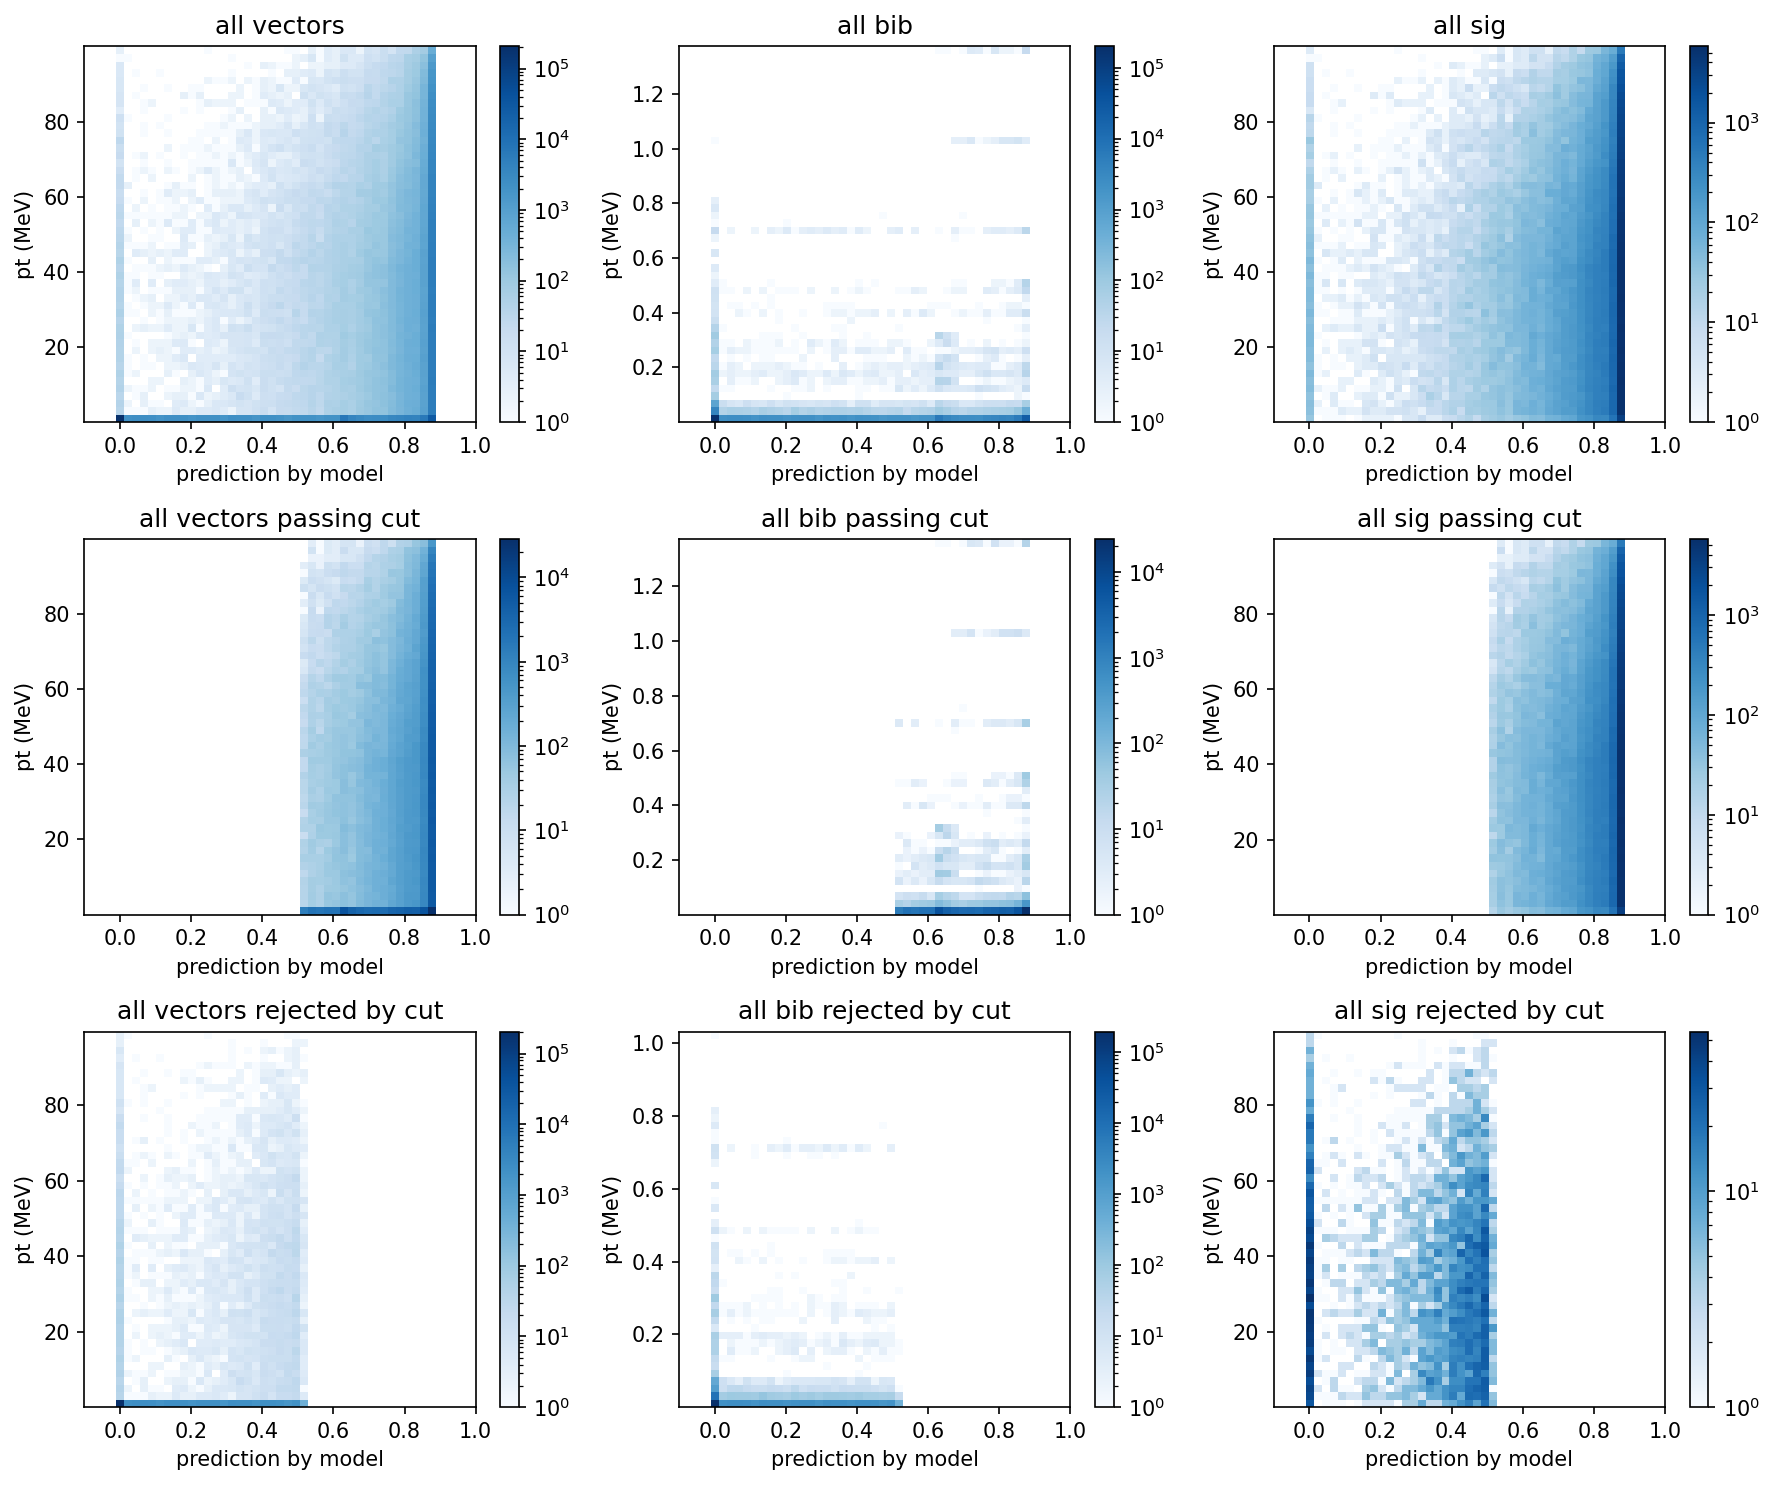

In [ ]:
# predVarDF["xSize"] = np.exp(predVarDF["xSize"])
# plt.hist(predVarDF["xSize"] )
# plt.show()
def plotXYSizeLocPerPred(predVarDF, cut = 0.51171875,pltDirAll = "./ratePlots/allVect",plotDirPass="./ratePlots/passPredict",plotDirRej="./ratePlots/rejPredict" ):
    
    dummyArray = [True for i in range(len(predVarDF.query("trueY == 0")))]
    plotZglobalXYsize(predVarDF.query("trueY == 0"),predVarDF.query("trueY == 1"),None,None,dummyArray,dummyArray,dummyArray,dummyArray,PLOT_DIR=pltDirAll)
    # plotYlocalXYsize(truthbib, truthsig, xSizesSig, xSizesBib, ySizesSig, ySizesBib,mask_bib,mask_sig,PLOT_DIR="./plots",interactivePlots=False):
    plotYlocalXYsize(predVarDF.query("trueY == 0"),predVarDF.query("trueY == 1"),None,None,None,None,dummyArray,dummyArray,PLOT_DIR=pltDirAll)
    plotPtEta(predVarDF.query("trueY == 1"),predVarDF.query("trueY == 0"),PLOT_DIR=pltDirAll)
    plotPt(predVarDF.query("trueY == 1"),predVarDF.query("trueY == 0"),predVarDF.query("trueY == 0"),predVarDF.query("trueY == 0"),PLOT_DIR=pltDirAll)
    # plotPtLowHigh(predVarDF.query("trueY == 0"),predVarDF.query("trueY == 1"),None,None,PLOT_DIR=pltDirAll)
               
    dummyArrayB = [True for i in range(len(predVarDF.query("trueY == 0 and prediction > @cut")))]
    dummyArrayS = [True for i in range(len(predVarDF.query("trueY == 1 and prediction > @cut")))]
    plotZglobalXYsize(predVarDF.query("trueY == 0 and prediction > @cut"),predVarDF.query("trueY == 1 and prediction > @cut"),None,None,dummyArrayS,dummyArrayB,dummyArrayB,dummyArrayS,PLOT_DIR=plotDirPass)
    plotYlocalXYsize(predVarDF.query("trueY == 0 and prediction > @cut"),predVarDF.query("trueY == 1 and prediction > @cut"),None,None,None,None,dummyArrayB,dummyArrayS,PLOT_DIR=plotDirPass)
    plotPtEta(predVarDF.query("trueY == 1 and prediction > @cut"),predVarDF.query("trueY == 0 and prediction > @cut"),PLOT_DIR=plotDirPass)
    plotPt(predVarDF.query("trueY == 1 and prediction > @cut"),predVarDF.query("trueY == 0 and prediction > @cut"),predVarDF.query("trueY == 0 and prediction > @cut"),predVarDF.query("trueY == 0 and prediction > @cut"),PLOT_DIR=plotDirPass)
    # plotPtLowHigh(predVarDF.query("trueY == 0 and prediction > @cut"),predVarDF.query("trueY == 1 and prediction > @cut"),None,None,PLOT_DIR=plotDirPass)


    dummyArrayB = [True for i in range(len(predVarDF.query("trueY == 0 and prediction < @cut")))]
    dummyArrayS = [True for i in range(len(predVarDF.query("trueY == 1 and prediction < @cut")))]
    plotZglobalXYsize(predVarDF.query("trueY == 0 and prediction < @cut"),predVarDF.query("trueY == 1 and prediction < @cut"),None,None,dummyArrayS,dummyArrayB,dummyArrayB,dummyArrayS,PLOT_DIR=plotDirRej)
    plotYlocalXYsize(predVarDF.query("trueY == 0 and prediction < @cut"),predVarDF.query("trueY == 1 and prediction < @cut"),None,None,None,None,dummyArrayB,dummyArrayS,PLOT_DIR=plotDirRej)
    plotPtEta(predVarDF.query("trueY == 1 and prediction < @cut"),predVarDF.query("trueY == 0 and prediction < @cut"),PLOT_DIR=plotDirRej)
    plotPt(predVarDF.query("trueY == 1 and prediction < @cut"),predVarDF.query("trueY == 0 and prediction < @cut"),predVarDF.query("trueY == 0 and prediction < @cut"),predVarDF.query("trueY == 0 and prediction < @cut"),PLOT_DIR=plotDirRej)
    # plotPtLowHigh(predVarDF.query("trueY == 0 and prediction < @cut"),predVarDF.query("trueY == 1 and prediction < @cut"),None,None,PLOT_DIR=plotDirRej)

def plotPtPrediction(truthDF,title="",setPredBins=True):
    mask = [True for i in range(len(truthDF))]
    if setPredBins:
        predBins = np.linspace(-0.1,1,50)
    else:
        predBins = 50
    plot2dHistFromTruth(truthDF,  "prediction","pt", mask, predBins, 50, "Blues", "prediction by model","pt (MeV)",title,logColor = True)
    # plot2dHist(truthBib["pt"],truthSig["pt"],  mask, binsX, binsY, cmap, xlabel,ylabel,title,logColor = False):

#Takes in the predVarDF which has the variable formated in plotUtils way, as well as a trueY for if bib/sig, and a prediction from model
#takes in the cut for the prediction
#takes in a plotting function, that must have 2 inputs (dataframe and title) to use to plot each subset of predVarDF
def plot3by3PredBibSig(predVarDF, cut = 0.51171875):
    plt.figure(figsize=(12,10))
    plt.subplot(331)
    plotPtPrediction(predVarDF,"all vectors")
    plt.subplot(332)
    plotPtPrediction(predVarDF.query("trueY == 0"),"all bib")
    plt.subplot(333)
    plotPtPrediction(predVarDF.query("trueY == 1"),"all sig")

    plt.subplot(334)
    plotPtPrediction(predVarDF.query("prediction > @cut"),"all vectors passing cut")
    plt.subplot(335)
    plotPtPrediction(predVarDF.query("trueY == 0 and prediction > @cut"),"all bib passing cut")
    plt.subplot(336)
    plotPtPrediction(predVarDF.query("trueY == 1 and prediction > @cut"),"all sig passing cut")

    plt.subplot(337)
    plotPtPrediction(predVarDF.query("prediction < @cut"),"all vectors rejected by cut")
    plt.subplot(338)
    plotPtPrediction(predVarDF.query("trueY == 0 and prediction < @cut"),"all bib rejected by cut")
    plt.subplot(339)
    plotPtPrediction(predVarDF.query("trueY == 1 and prediction < @cut"),"all sig rejected by cut")
    plt.tight_layout()
    plt.show()


def plot2dHistForModelPred(model,predictions): #refine, then once done use it into script
    predVarDF = getPredVarDF(model,predictions)
    # keys = ["nModule","x_local","y_local","nPix"]
    # # {}
    #undo normalization
    predVarDF["xSize"] = 21*(predVarDF["xSize"])
    predVarDF["ySize"] = 13*(predVarDF["ySize"])
    plotXYSizeLocPerPred(predVarDF)

plot3by3PredBibSig(predVarDF)

# plotXYSizeLocPerPred(predVarDF)


In [11]:
nPixes, yTest = getNpixYtest(model)

In [12]:
# model.evaluate(config_name = configName)

predictions = model.models[configName].predict(model.validation_generator, verbose=1)
print(predictions)
predictions = predictions.ravel()


41/41 [==============================] - 3s 63ms/step
[[0.8359375]
 [0.859375 ]
 [0.       ]
 ...
 [0.875    ]
 [0.15625  ]
 [0.       ]]


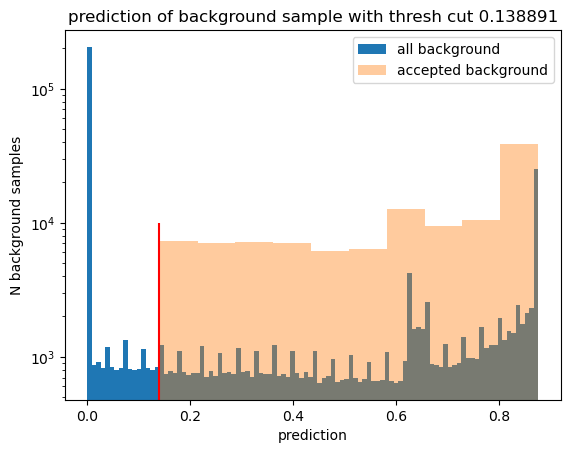


accepted background samples:  112434
total background samples:  330741
backgorund acceptance:  0.3399457581612198
Total background pixel count:  2000084.0
Accepted background pixel count:  482465.0
Data rate of background acceptance:  0.24122237


(482465.0, 2000084.0, 0.24122237)

In [13]:
# nPixes = xTestWithNpix["nPix"]
#functions moved to script
dataRateUtils.pixPredictToDataRate(yTest,nPixes,predictions)


In [ ]:
#functions moved to script
raise ValueError("Definitely end here")


In [15]:
xTest, yTest, xTestList, xTrain, yTrain = flattenTfData(1)

Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 164
Validation generator length: 41


KeyboardInterrupt: 

[0.14285715 0.14285715 0.0952381  ... 0.04761905 0.14285715 0.0952381 ]


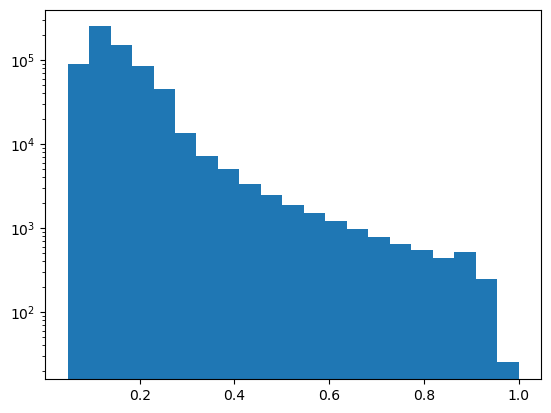

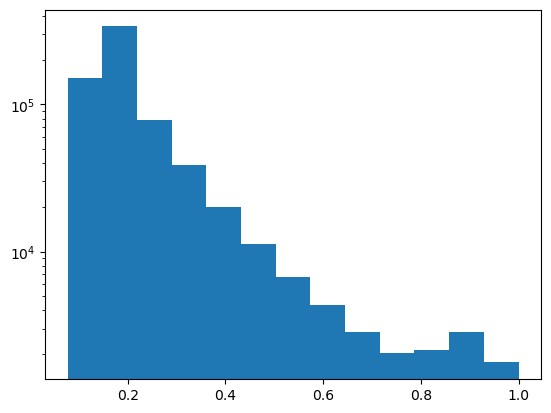

In [ ]:
print(xTest["x_size"].numpy())
plt.hist(xTest["x_size"].numpy(),bins=21)
plt.yscale('log')
plt.show()
plt.hist(xTest["y_size"].numpy(),bins =13)
plt.yscale('log')
plt.show()

In [ ]:
plt.hist(xTest["y_size"])